# Driver Model — Grayscale Training\n\nSame dataset as `model_training.ipynb`, but images are converted to **grayscale**\nbefore entering the network.\n\nUses the **simple 3-conv + 2-fc model** with `Conv2d(1, ...)` as the first layer\n(1 input channel instead of 3). No pretrained weights — trained from scratch.\n\nOutputs → `driver_model_gray.pth` (best val loss) and `driver_model_gray_final.pth`.

In [2]:
import os
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from tqdm import tqdm

FUTURE_OFFSET = 5
BATCH_SIZE    = 32
NUM_EPOCHS    = 30
LR            = 1e-4
DATA_ROOT     = '../../dataset/'
SAVE_BEST     = 'driver_model_gray.pth'
SAVE_FINAL    = 'driver_model_gray_final.pth'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda



## 1 · Dataset

Images are loaded and converted to **grayscale** (`'L'` mode → single channel).  
`future_offset` shifts the target label forward in time so the model learns
to anticipate the next steering command.

In [3]:
class DrivingDataset(Dataset):
    def __init__(self, root_dir, transform=None, future_offset=0):
        self.transform = transform
        self.samples = []

        for file in sorted(os.listdir(root_dir)):
            if not file.endswith('.csv'):
                continue
            csv_path    = os.path.join(root_dir, file)
            folder_path = os.path.join(root_dir, file.replace('.csv', ''))
            if not os.path.isdir(folder_path):
                continue

            df = pd.read_csv(csv_path).reset_index(drop=True)
            for i in range(len(df) - future_offset):
                img_row    = df.iloc[i]
                target_row = df.iloc[i + future_offset]
                img_path   = os.path.join(folder_path, img_row['img_id'])
                if os.path.exists(img_path):
                    self.samples.append({
                        'image_path': img_path,
                        'forward':    float(target_row['forward']),
                        'turn':       float(target_row['turn']),
                    })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        # Convert to grayscale — single 2-D (H×W) image, no colour channels
        image = Image.open(s['image_path']).convert('L')
        if self.transform:
            image = self.transform(image)
        target = torch.tensor([s['forward'], s['turn']], dtype=torch.float32)
        return image, target


# Grayscale ImageNet-equivalent stats (luminance approximation)
GRAY_MEAN = [0.449]
GRAY_STD  = [0.226]

data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),                          # (1, H, W) float in [0,1]
    transforms.Normalize(mean=GRAY_MEAN, std=GRAY_STD),
])

full_dataset = DrivingDataset(
    root_dir=DATA_ROOT,
    transform=data_transforms,
    future_offset=FUTURE_OFFSET,
)
print(f'FUTURE_OFFSET = {FUTURE_OFFSET} frames')
print(f'Total samples: {len(full_dataset)}')

train_size = int(0.9 * len(full_dataset))
val_size   = len(full_dataset) - train_size
train_ds, val_ds = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train: {train_size}  Val: {val_size}')

imgs, tgts = next(iter(train_loader))
print(f'Image batch shape : {imgs.shape}   (batch, 1-channel-gray, H, W)')
print(f'Target batch shape: {tgts.shape}')

FUTURE_OFFSET = 5 frames
Total samples: 7599
Train: 6839  Val: 760
Image batch shape : torch.Size([32, 1, 224, 224])   (batch, 1-channel-gray, H, W)
Target batch shape: torch.Size([32, 2])


## 2 · Model\n\nSimple 3-conv + 2-fc network. First conv takes **1 channel** (grayscale) instead of 3.\nThe flattened size after the three conv layers is still **40 000** — spatial dimensions\nare unchanged by the number of input channels.

In [ ]:
class DriverModelGray(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1   = nn.Conv2d(1, 16, kernel_size=5, stride=2)   # 1 channel — grayscale
        self.conv2   = nn.Conv2d(16, 32, kernel_size=5, stride=2)
        self.conv3   = nn.Conv2d(32, 64, kernel_size=5, stride=2)
        self.dropout = nn.Dropout(p=0.4)
        self.fc1     = nn.Linear(40000, 256)  # 64 × 25 × 25 = 40 000
        self.fc2     = nn.Linear(256, 2)

    def forward(self, x):          # x: (B, 1, 224, 224)
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = torch.relu(self.conv3(x))
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)         # (B, 2) — [forward, turn]


model = DriverModelGray().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {n_params:,}')

# Sanity-check shape
with torch.no_grad():
    dummy = torch.zeros(1, 1, 224, 224, device=device)
    out   = model(dummy)
    print(f'Output shape for (1,1,224,224) input: {out.shape}  ← (batch, [forward, turn])')

Parameters: 10,305,282
Output shape for (1,1,224,224) input: torch.Size([1, 2])  ← (batch, [forward, turn])


## 3 · Training loop

In [5]:
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

best_val_loss  = float('inf')
history_train  = []
history_val    = []

for epoch in tqdm(range(NUM_EPOCHS), desc='Epochs'):
    # ── Train ──
    model.train()
    running = 0.0
    for imgs, tgts in train_loader:
        imgs, tgts = imgs.to(device), tgts.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), tgts)
        loss.backward()
        optimizer.step()
        running += loss.item() * imgs.size(0)
    train_loss = running / train_size

    # ── Validate ──
    model.eval()
    running = 0.0
    with torch.no_grad():
        for imgs, tgts in val_loader:
            imgs, tgts = imgs.to(device), tgts.to(device)
            running += criterion(model(imgs), tgts).item() * imgs.size(0)
    val_loss = running / val_size

    scheduler.step()
    history_train.append(train_loss)
    history_val.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), SAVE_BEST)

    print(f'Epoch [{epoch+1:02d}/{NUM_EPOCHS}]  '
          f'train={train_loss:.4f}  val={val_loss:.4f}  '
          f'lr={scheduler.get_last_lr()[0]:.6f}')

torch.save(model.state_dict(), SAVE_FINAL)
print(f'\nBest val loss: {best_val_loss:.4f}')
print(f'Saved best  → {SAVE_BEST}')
print(f'Saved final → {SAVE_FINAL}')

Epochs:   3%|▎         | 1/30 [01:02<30:03, 62.19s/it]

Epoch [01/30]  train=0.0578  val=0.0326  lr=0.000100


Epochs:   7%|▋         | 2/30 [01:57<27:06, 58.09s/it]

Epoch [02/30]  train=0.0320  val=0.0273  lr=0.000099


Epochs:  10%|█         | 3/30 [02:52<25:37, 56.95s/it]

...

Epoch [28/30]  train=0.0045  val=0.0197  lr=0.000001


Epochs:  97%|█████████▋| 29/30 [18:46<00:11, 11.67s/it]

Epoch [29/30]  train=0.0045  val=0.0196  lr=0.000000


Epochs: 100%|██████████| 30/30 [18:57<00:00, 37.91s/it]

Epoch [30/30]  train=0.0045  val=0.0196  lr=0.000000

Best val loss: 0.0196
Saved best  → driver_model_gray.pth
Saved final → driver_model_gray_final.pth


## 4 · Loss curves

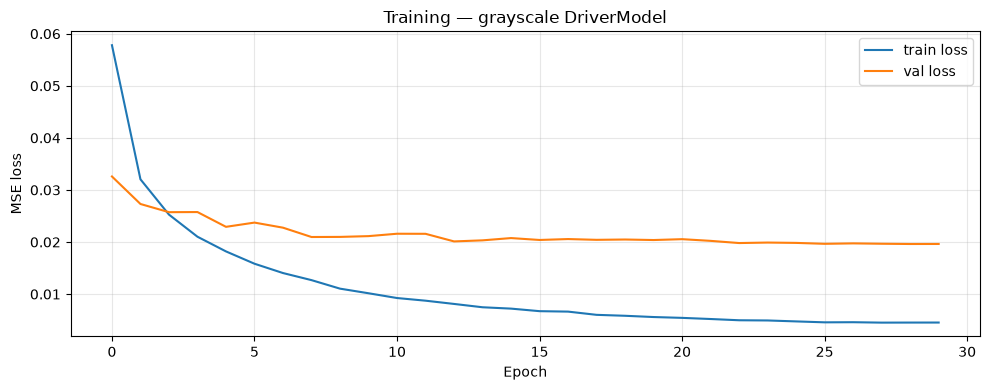

Saved → loss_curve_gray.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_train, label='train loss')
ax.plot(history_val,   label='val loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_title('Training — grayscale DriverModel')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve_gray.png', dpi=120)
plt.show()
print('Saved → loss_curve_gray.png')

## 5 · Quick verification — reload and run a batch

In [7]:
check_model = DriverModelGray()
check_model.load_state_dict(torch.load(SAVE_BEST, map_location='cpu'))
check_model.eval()

imgs, tgts = next(iter(val_loader))
with torch.no_grad():
    preds = check_model(imgs)   # (B, 2)

print('Sample predictions vs ground truth (first 8):')
print(f'{"pred_fwd":>10} {"gt_fwd":>10} {"pred_turn":>12} {"gt_turn":>10}')
for p, g in zip(preds[:8], tgts[:8]):
    print(f'{p[0].item():+10.4f} {g[0].item():+10.4f} {p[1].item():+12.4f} {g[1].item():+10.4f}')

Sample predictions vs ground truth (first 8):
  pred_fwd     gt_fwd    pred_turn    gt_turn
   -1.0225    -1.0000      -0.4073    -0.4980
   -1.0184    -1.0000      -0.2413    +0.0000
   -0.9842    -1.0000      +0.0656    +0.8902
   -1.0057    -1.0000      -0.6776    +0.0000
   -1.0043    -1.0000      -0.0034    +0.0000
   -1.0221    -1.0000      +0.2655    +0.3961
   -0.9899    -1.0000      -0.0582    +0.0000
   -1.0057    -1.0000      +0.0042    +0.0000
